## RFM Analysis (RFM Table)
* `The goal of RFM is to understand who our customers are and how they behave.`

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rfm_table = pd.read_csv('rfm_table.csv')
rfm_table.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [3]:
rfm_table.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,306.482500
50%,15299.500000,50.000000,2.000000,668.570000
75%,16778.750000,141.000000,5.000000,1660.597500
max,18287.000000,373.000000,209.000000,280206.020000


In [ ]:
rfm_log = rfm_table.copy()
rfm_log[['Recency','Frequency','Monetary']] = np.log1p(
    rfm_log[['Recency','Frequency','Monetary']]
)
'''The purpose of the log is to make the distribution clear, reduce the impact of large values,
and help you better understand customer behavior visually.'''

array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Recency'}>],
       [<Axes: title={'center': 'Frequency'}>,
        <Axes: title={'center': 'Monetary'}>]], dtype=object)

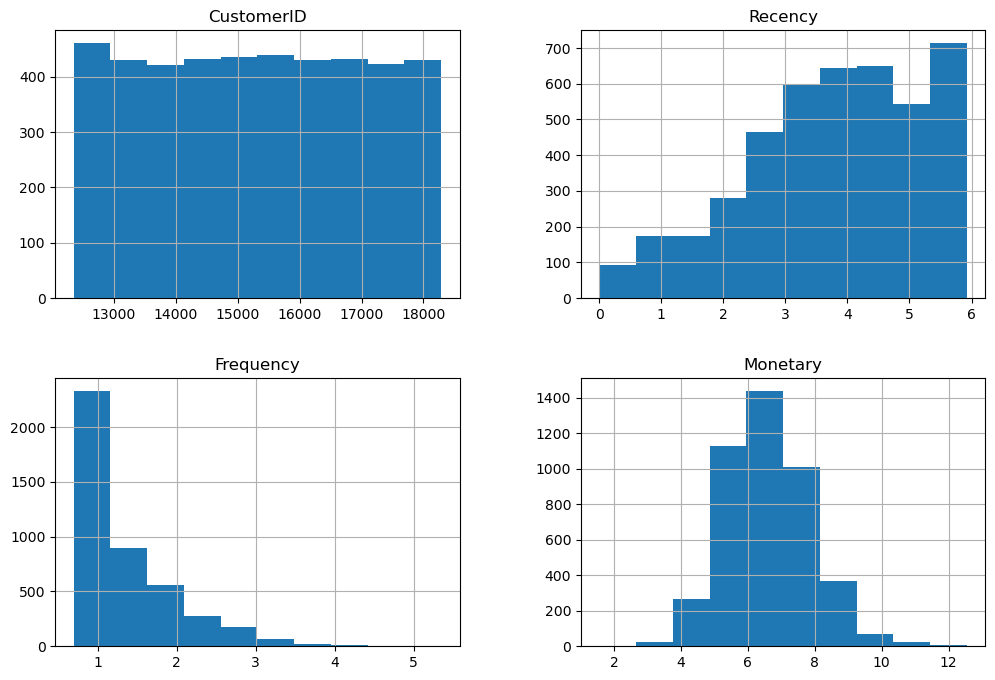

In [8]:
rfm_log.hist(figsize=(12, 8))

### Most customers have low frequency → Loyalty problem
### A few spend a lot → VIP customers
### Most customers spend a little
### Most customers have high Recency → Problem of losing customers

* Top 10 customers contribute major revenue share👇👇

In [9]:
rfm_table.sort_values('Monetary', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary
1689,14646,1,73,280206.02
4201,18102,0,60,259657.30
3728,17450,7,46,194390.79
3008,16446,0,2,168472.50
1879,14911,0,201,143711.17
55,12415,23,21,124914.53
1333,14156,9,55,117210.08
3771,17511,2,31,91062.38
2702,16029,38,63,80850.84
0,12346,325,1,77183.60


* calculate corrlation

In [10]:
rfm_table[['Monetary' , 'Recency' , 'Frequency']].corr()

,Monetary,Recency,Frequency
Monetary,1.000000,-0.121831,0.552780
Recency,-0.121831,1.000000,-0.260578
Frequency,0.552780,-0.260578,1.000000


* Simple basic division (Rule-based Segments)

In [11]:
def label(row):
    if row['Recency'] < 30 and row['Frequency'] > 5:
        return 'Loyal'
    elif row['Recency'] > 100:
        return 'Lost'
    else:
        return 'Regular'

rfm_table['Segment'] = rfm_table.apply(label, axis=1)

rfm_table.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,325,1,77183.60,Lost
1,12347,1,7,4310.00,Loyal
2,12348,74,4,1797.24,Regular
3,12349,18,1,1757.55,Regular
4,12350,309,1,334.40,Lost


In [13]:
No_each_segment = rfm_table['Segment'].value_counts()
No_each_segment

Segment
Regular    2326
Lost       1353
Loyal       659
Name: count, dtype: int64

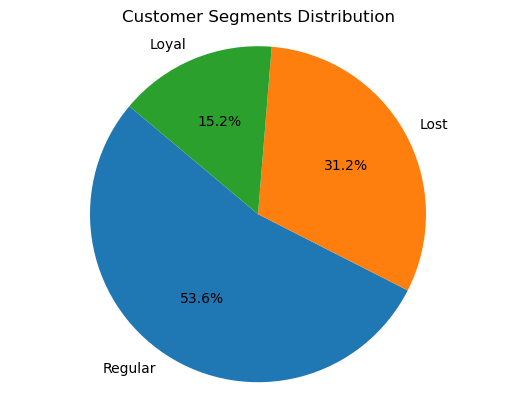

In [14]:
plt.pie(No_each_segment, labels=No_each_segment.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer Segments Distribution') 
plt.axis('equal')
plt.show()

## Customer Insights:
* 1- Most customers make infrequent purchases.
* 2- A small number of customers generate the majority of revenue.
* 3- There are customers who are inactive for extended periods.
* 4- The data contains powerful outliers.